In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import mannwhitneyu

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi']  = 120
plt.rcParams['savefig.dpi'] = 150

# ── Global figure font sizes (used across all figures in this notebook) ──────
TITLE_FONT_SIZE = 12   # subplot titles, suptitles
AXIS_FONT_SIZE  = 11   # axis labels (x/y/supxlabel) and tick labels

ROOT = Path('..').resolve()
FIGS = ROOT / 'figures'
FIGS.mkdir(exist_ok=True)

ACCENT_COLORS = {
    'American': '#9B72CF', 'British': '#457B9D',
    'Chinese':  '#F4A261', 'Indian':  '#2A9D8F', 'Nigerian': '#E63946',
}
MODEL_COLORS = {
    'Gemini-2.5-Flash': '#DD8452', 'GPT-4o':   '#E74C3C',
    'Qwen':             '#8172B2', 'Voxtral':  '#55A868', 'Flamingo': '#4C72B0',
}
PAPER_ACCENTS = ['American', 'British', 'Chinese', 'Indian', 'Nigerian']
NON_AM        = ['British', 'Chinese', 'Indian', 'Nigerian']
MODELS_ORDER  = ['Gemini-2.5-Flash', 'GPT-4o', 'Qwen', 'Voxtral', 'Flamingo']

## Load all result CSVs

- **Human hiring corpus** — critical prompt only
- **Synthetic hiring corpus** — critical prompt only (only figure 4 will need three for sensivity test)
- **XLS-R acoustic distances** — human and synthetic
- **ASR transcripts** — Gemini and Qwen

In [2]:
# ── Human hiring corpus (critical prompt only) ────────────────────────────────

CORPUS_FILES = {
    'Gemini-2.5-Flash': 'gemini-2.5-flash_hiring_corpus.csv',
    'GPT-4o':           'gpt-4o-audio-preview_hiring_corpus.csv',
    'Qwen':             'qwen_hiring_corpus.csv',
    'Voxtral':          'voxtral_hiring_corpus.csv',
    'Flamingo':         'flamingo_hiring_corpus.csv',
}
# ── Synthetic hiring corpus (critical prompt only) ────────────────────────────

SYNTH_CRITICAL_FILES = {
    'Gemini-2.5-Flash': 'gemini-2.5-flash_hiring_synthetic_critical.csv',
    'GPT-4o':           'gpt-4o-audio-preview_hiring_synthetic_critical.csv',
    'Qwen':             'qwen_hiring_synthetic_critical.csv',
    'Voxtral':          'voxtral_hiring_synthetic_critical.csv',
    'Flamingo':         'flamingo_hiring_synthetic_critical.csv',
}

# ── XLS-R acoustic distances ───────────────────────────────────────────────────

XLSR_HUMAN_FILES = {
    'personal-introduction': 'word_distances_personal_intro.csv',
    'personal-commitment':   'word_distances_commitment.csv',
    'financial-product':     'word_distances_financial.csv',
    'client-disagreement':   'word_distances_disagreement.csv',
}
XLSR_SYNTH_FILES = {
    'personal-introduction': 'word_distances_personal_intro.csv',
    'personal-commitment':   'word_distances_commitment.csv',
    'financial-product':     'word_distances_financial.csv',
    'client-disagreement':   'word_distances_disagreement.csv',
}


In [3]:
def _extract_rating(text):
    m = re.search(r'Rating:\s*(\d)', str(text))
    return int(m.group(1)) if m else np.nan

def _normalize_accent(raw):
    raw = str(raw).strip()
    for a in PAPER_ACCENTS:
        if a.lower() in raw.lower():
            return a
    return None

def _zscore(df, groups, val='rating', out='z'):
    df = df.copy()
    g  = df.groupby(groups)[val]
    df[out] = (df[val] - g.transform('mean')) / g.transform('std')
    return df


# ── Human hiring corpus (critical prompt only) ────────────────────────────────

corpus_parts = []
for mlabel, fname in CORPUS_FILES.items():
    p = ROOT / 'results' / 'hiring_corpus' / fname
    if not p.exists():
        print(f'WARNING: missing {fname}')
        continue
    df = pd.read_csv(p)
    df = df[df['prompt_type'] == 'critical'].copy()
    df['model_label'] = mlabel
    corpus_parts.append(df)

corpus = pd.concat(corpus_parts, ignore_index=True)
corpus['rating'] = corpus['model_output'].apply(_extract_rating)
corpus['accent'] = corpus['accent_nationality_origin'].apply(_normalize_accent)
corpus = corpus[corpus['accent'].notna() & corpus['rating'].notna()].copy()
corpus = _zscore(corpus, ['model_label', 'script_type', 'category'])
print(f"Human corpus (critical): {len(corpus):,} rows | "
      f"accents: {corpus['accent'].value_counts().to_dict()}")


# ── Synthetic hiring corpus (critical prompt only) ────────────────────────────


synth_parts = []
for mlabel, fname in SYNTH_CRITICAL_FILES.items():
    p = ROOT / 'results' / 'hiring_synthetic' / fname
    if not p.exists():
        print(f'WARNING: missing {fname}')
        continue
    df = pd.read_csv(p)
    df['model_label'] = mlabel
    df['prompt_type'] = 'critical'
    synth_parts.append(df)

synth = pd.concat(synth_parts, ignore_index=True)
synth['rating'] = synth['model_output'].apply(_extract_rating)
synth['accent'] = synth['accent'].apply(_normalize_accent)
synth = synth[synth['accent'].isin(PAPER_ACCENTS) & synth['rating'].notna()].copy()
synth = synth.drop_duplicates(subset=['model_label', 'script_type', 'accent', 'voice_id', 'category'])
synth = _zscore(synth, ['model_label', 'script_type', 'category'])
print(f"Synthetic corpus (critical): {len(synth):,} rows | "
      f"accents: {synth['accent'].value_counts().to_dict()}")


# ── XLS-R acoustic distances ───────────────────────────────────────────────────


def _load_xlsr(file_map, subdir):
    parts = []
    base  = ROOT / 'results' / 'phone_distance_distances_only' / subdir
    for cat, fname in file_map.items():
        p = base / fname
        if not p.exists():
            print(f'WARNING: missing {fname}')
            continue
        df = pd.read_csv(p)
        df['category'] = cat
        parts.append(df)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

xlsr_human = _load_xlsr(XLSR_HUMAN_FILES, 'human')
xlsr_synth = _load_xlsr(XLSR_SYNTH_FILES, 'synthetic')
print(f"XLS-R human: {len(xlsr_human):,} word-speaker rows | "
      f"speakers: {xlsr_human['speaker_id'].nunique()}")
print(f"XLS-R synthetic: {len(xlsr_synth):,} word-speaker rows")


# ── ASR transcripts ────────────────────────────────────────────────────────────

asr_parts = []
for fname in ['gemini-2.5-flash_asr_transcript.csv', 'qwen_asr_transcript.csv']:
    p = ROOT / 'results' / 'asr_transcript' / fname
    if not p.exists():
        print(f'WARNING: missing {fname}')
        continue
    asr_parts.append(pd.read_csv(p))

asr = pd.concat(asr_parts, ignore_index=True)
print(f"ASR: {len(asr):,} rows | models: {list(asr['model'].unique())}")

Human corpus (critical): 2,795 rows | accents: {'Nigerian': 755, 'American': 704, 'Chinese': 589, 'Indian': 532, 'British': 215}
Synthetic corpus (critical): 1,198 rows | accents: {'American': 240, 'Nigerian': 240, 'British': 240, 'Chinese': 239, 'Indian': 239}
XLS-R human: 13,897 word-speaker rows | speakers: 52
XLS-R synthetic: 7,698 word-speaker rows
ASR: 416 rows | models: ['gemini-2.5-flash', 'qwen']


Gap computation and significance

Z-scores are computed within each *(model × script\_type × scenario)* cell.
Gap = mean z(accent) − mean z(American), speaker-level aggregation.
Significance: two-sided Mann-Whitney U, BH-FDR correction across 20 tests (5 models × 4 accent groups).

In [4]:
def _gap_ci(df, speaker_col):
    """95% CI for gap = accent z − American z, speaker-level."""
    spk  = df.groupby(['model_label', 'accent', speaker_col])['z'].mean().reset_index()
    rows = []
    for m in MODELS_ORDER:
        am_z = spk[(spk['model_label'] == m) & (spk['accent'] == 'American')]['z'].values
        for acc in PAPER_ACCENTS:
            a_z = spk[(spk['model_label'] == m) & (spk['accent'] == acc)]['z'].values
            if len(a_z) == 0 or len(am_z) == 0:
                half_ci = np.nan
            else:
                var_a  = np.var(a_z,  ddof=1) if len(a_z)  > 1 else 0.0
                var_am = np.var(am_z, ddof=1) if len(am_z) > 1 else 0.0
                half_ci = 1.96 * np.sqrt(var_a / len(a_z) + var_am / len(am_z))
            rows.append({'model_label': m, 'accent': acc, 'half_ci': half_ci})
    return pd.DataFrame(rows)

def compute_gap(df, script_filter, speaker_col='name'):
    sub = df[df['script_type'] == script_filter].copy()
    spk = sub.groupby(['model_label', 'accent', speaker_col])['z'].mean().reset_index()
    am  = spk[spk['accent'] == 'American'].groupby('model_label')['z'].mean()
    spk['gap'] = spk.apply(lambda r: r['z'] - am.get(r['model_label'], 0.0), axis=1)
    return spk.groupby(['model_label', 'accent'])['gap'].mean().reset_index()

corp_del  = compute_gap(corpus, 'delivery', 'name')
corp_con  = compute_gap(corpus, 'content',  'name')
synth_del = compute_gap(synth,  'delivery', 'voice_id')


def _bh_fdr(ps):
    ps    = np.array(ps, dtype=float)
    n     = len(ps)
    order = np.argsort(ps)
    rank  = np.empty(n); rank[order] = np.arange(1, n + 1)
    p_adj = np.minimum(1.0, ps * n / rank)
    for i in range(n - 2, -1, -1):
        p_adj[order[i]] = min(p_adj[order[i]], p_adj[order[i + 1]])
    return np.minimum(1.0, p_adj)

def _stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '†'
    return ''

spk_del = (corpus[corpus['script_type'] == 'delivery']
           .groupby(['model_label', 'accent', 'name'])['z'].mean().reset_index())

sig_rows = []
for m in MODELS_ORDER:
    am_z = spk_del[(spk_del['model_label'] == m) & (spk_del['accent'] == 'American')]['z']
    for acc in NON_AM:
        a_z = spk_del[(spk_del['model_label'] == m) & (spk_del['accent'] == acc)]['z']
        _, p = mannwhitneyu(a_z, am_z, alternative='two-sided') if (len(a_z) >= 2 and len(am_z) >= 2) else (np.nan, 1.0)
        sig_rows.append({'model': m, 'accent': acc, 'p_raw': p})

sig_df = pd.DataFrame(sig_rows)
sig_df['p_fdr'] = _bh_fdr(sig_df['p_raw'])
sig_df['stars'] = sig_df['p_fdr'].apply(_stars)
stars_lookup = {(r.model, r.accent): r.stars for _, r in sig_df.iterrows()}

print('Significance (BH-FDR, delivery z-gap vs. American):')
print(sig_df.pivot(index='accent', columns='model', values='stars')
      .reindex(index=NON_AM, columns=MODELS_ORDER).to_string())
print()
print('FDR p-values:')
print(sig_df.pivot(index='accent', columns='model', values='p_fdr')
      .reindex(index=NON_AM, columns=MODELS_ORDER).round(3).to_string())

Significance (BH-FDR, delivery z-gap vs. American):
model    Gemini-2.5-Flash GPT-4o Qwen Voxtral Flamingo
accent                                                
British                                               
Chinese                             *                 
Indian                                      †         
Nigerian                            *       †         

FDR p-values:
model     Gemini-2.5-Flash  GPT-4o   Qwen  Voxtral  Flamingo
accent                                                      
British              0.763   0.949  0.344    0.223     0.302
Chinese              0.673   0.205  0.031    0.154     1.000
Indian               0.949   0.457  0.223    0.099     0.949
Nigerian             0.344   0.154  0.021    0.099     0.452


## Figure 1 — Delivery z-score gaps, human hiring corpus (critical prompt)

**Corpus:** Human hiring · **Prompt:** critical · **Dimension:** delivery · **Scenarios:** all (4 scripted + 2 unscripted) · **Gap:** speaker-level mean z(accent) − mean z(American)

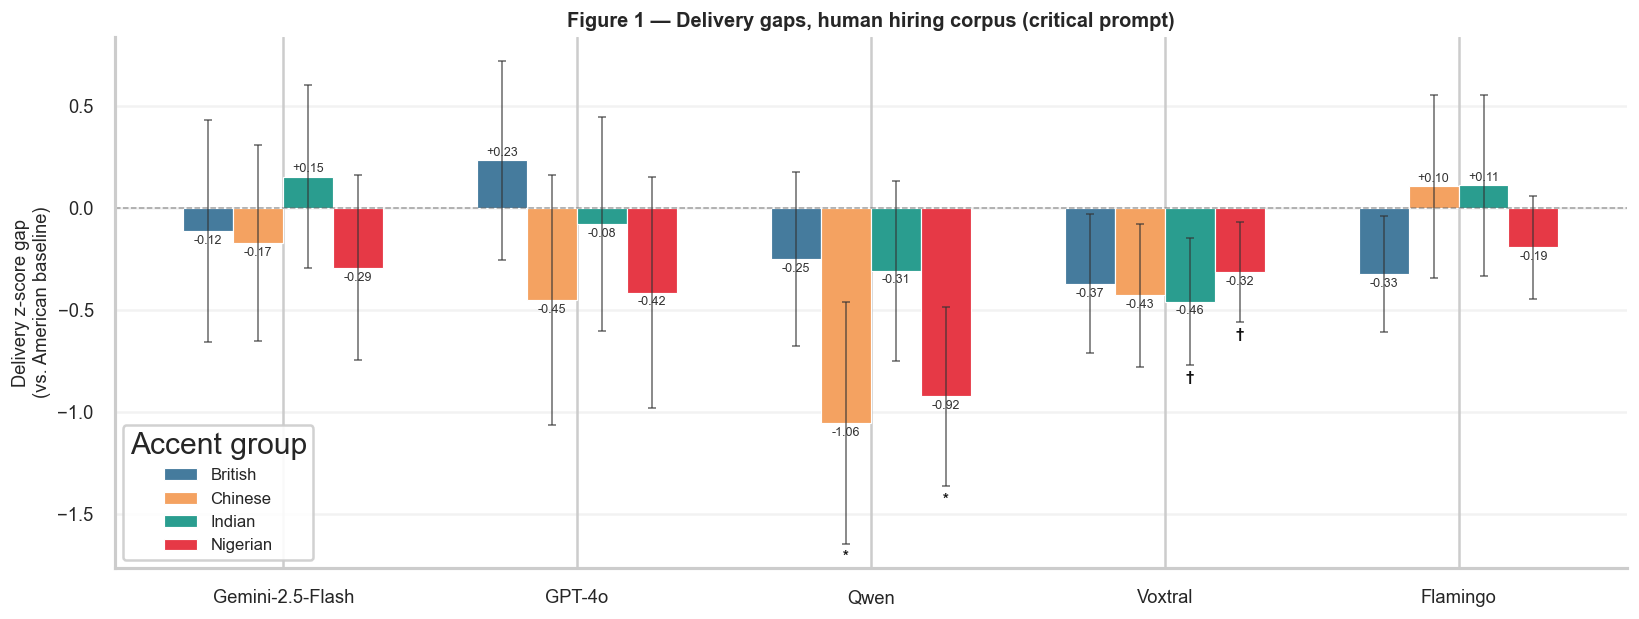

Saved: fig1a_human_delivery_by_model.pdf


In [5]:
# Figure 1 — delivery z-score gaps, human hiring corpus (critical prompt)
corp_del_ci = _gap_ci(corpus[corpus['script_type'] == 'delivery'], 'name')
corp_del_na = corp_del[corp_del['accent'] != 'American']

w       = 0.17
x       = np.arange(len(MODELS_ORDER))
offsets = np.linspace(-(len(NON_AM) - 1) / 2, (len(NON_AM) - 1) / 2, len(NON_AM)) * w

fig, ax = plt.subplots(figsize=(14, 5.5))
for i, acc in enumerate(NON_AM):
    vals = [float(corp_del_na[(corp_del_na['model_label'] == m) &
                               (corp_del_na['accent'] == acc)]['gap'].iloc[0])
            if len(corp_del_na[(corp_del_na['model_label'] == m) &
                                (corp_del_na['accent'] == acc)]) else np.nan
            for m in MODELS_ORDER]
    cis  = [float(corp_del_ci[(corp_del_ci['model_label'] == m) &
                               (corp_del_ci['accent'] == acc)]['half_ci'].iloc[0])
            if len(corp_del_ci[(corp_del_ci['model_label'] == m) &
                                (corp_del_ci['accent'] == acc)]) else np.nan
            for m in MODELS_ORDER]
    bars = ax.bar(x + offsets[i], vals, w,
                  label=acc, color=ACCENT_COLORS[acc], edgecolor='white', linewidth=0.7,
                  yerr=cis, capsize=2.5,
                  error_kw={'elinewidth': 0.9, 'ecolor': '#333', 'capthick': 0.9, 'alpha': 0.75})
    for bar, v, ci, m in zip(bars, vals, cis, MODELS_ORDER):
        bx = bar.get_x() + bar.get_width() / 2
        ly = v + (-0.018 if v < 0 else 0.008)
        if   0 <= v < 0.025:  ly =  0.013
        elif -0.025 < v < 0:  ly = -0.013
        ax.text(bx, ly, f'{v:+.2f}',
                ha='center', va='top' if v < 0 else 'bottom', fontsize=7.5, color='#333')
        star = stars_lookup.get((m, acc), '')
        if star:
            sy = (v + ci + 0.030) if v >= 0 else (v - ci - 0.030)
            ax.text(bx, sy, star, ha='center',
                    va='bottom' if v >= 0 else 'top', fontsize=9, fontweight='bold', color='#111')

ax.axhline(0, color='#555', linewidth=0.9, linestyle='--', alpha=0.55)
ax.set_xticks(x)
ax.set_xticklabels(MODELS_ORDER, fontsize=AXIS_FONT_SIZE)
ax.tick_params(axis='y', labelsize=AXIS_FONT_SIZE)
ax.set_ylabel('Delivery z-score gap\n(vs. American baseline)', fontsize=AXIS_FONT_SIZE)
ax.set_title('Figure 1 — Delivery gaps, human hiring corpus (critical prompt)',
             fontsize=TITLE_FONT_SIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Accent group', framealpha=0.9, fontsize=10, loc='lower left')
fig.tight_layout()
fig.savefig(FIGS / 'fig1a_human_delivery_by_model.pdf', bbox_inches='tight')
plt.show()
print('Saved: fig1a_human_delivery_by_model.pdf')

FIGURE 1 WITH speaker_26 REVISIONS

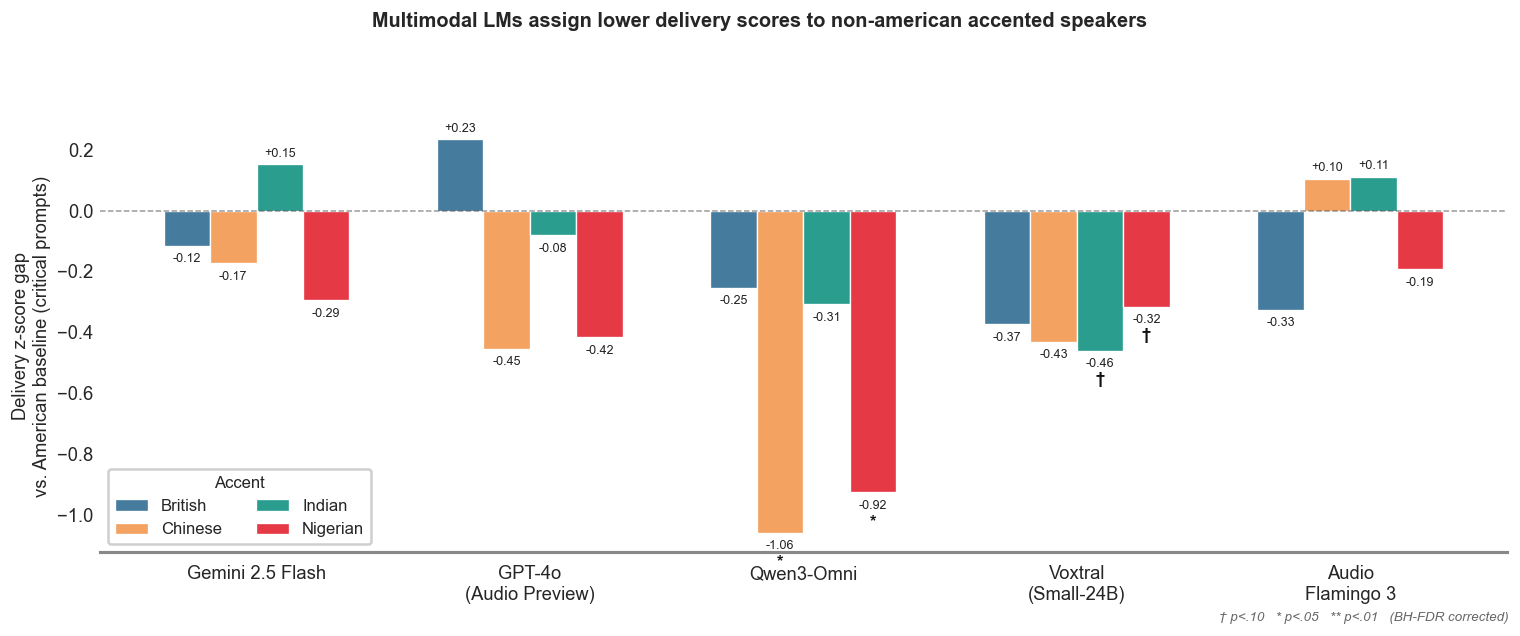

Saved: fig1b_revised_zscores_by_accent.pdf


In [6]:
# Figure 1 (revised)
# - Y-axis = delivery z-score gap vs. American baseline (gap = mean_z(accent) - mean_z(American))
# - Critical prompt only (corpus is already filtered to critical)

MODEL_DISPLAY = {
    'Gemini-2.5-Flash': 'Gemini 2.5 Flash',
    'GPT-4o':           'GPT-4o\n(Audio Preview)',
    'Qwen':             'Qwen3-Omni',
    'Voxtral':          'Voxtral\n(Small-24B)',
    'Flamingo':         'Audio\nFlamingo 3',
}

w       = 0.17
x       = np.arange(len(MODELS_ORDER))
offsets = np.linspace(-(len(NON_AM) - 1) / 2, (len(NON_AM) - 1) / 2, len(NON_AM)) * w

fig, ax = plt.subplots(figsize=(13, 5))

for i, acc in enumerate(NON_AM):
    vals = [float(corp_del_na[(corp_del_na['model_label'] == m) &
                               (corp_del_na['accent'] == acc)]['gap'].iloc[0])
            if len(corp_del_na[(corp_del_na['model_label'] == m) &
                                (corp_del_na['accent'] == acc)]) else np.nan
            for m in MODELS_ORDER]
    bars = ax.bar(x + offsets[i], vals, w,
                  label=acc, color=ACCENT_COLORS[acc], edgecolor='white', linewidth=0.8)
    for bar, v, m in zip(bars, vals, MODELS_ORDER):
        if np.isnan(v):
            continue
        bx = bar.get_x() + bar.get_width() / 2
        ly = v + (-0.025 if v < 0 else 0.015)
        if   0    <= v <  0.03: ly =  0.015
        elif -0.03 < v <  0:   ly = -0.015
        ax.text(bx, ly, f'{v:+.2f}',
                ha='center', va='top' if v < 0 else 'bottom', fontsize=7.5, color='#222')
        star = stars_lookup.get((m, acc), '')
        if star:
            sy = v + (0.07 if v >= 0 else -0.07)
            ax.text(bx, sy, star,
                    ha='center', va='bottom' if v >= 0 else 'top',
                    fontsize=10, fontweight='bold', color='#111')

ax.axhline(0, color='#333', linewidth=0.9, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels([MODEL_DISPLAY[m] for m in MODELS_ORDER], fontsize=AXIS_FONT_SIZE)
ax.tick_params(axis='y', labelsize=AXIS_FONT_SIZE)
ax.set_ylabel('Delivery z-score gap\nvs. American baseline (critical prompts)', fontsize=AXIS_FONT_SIZE)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#888')
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=4, color='#888')
ax.grid(False)
ax.legend(title='Accent', fontsize=10, title_fontsize=10,
          framealpha=0.95, loc='lower left', ncol=2)
fig.text(0.98, 0.02,
         '† p<.10   * p<.05   ** p<.01   (BH-FDR corrected)',
         ha='right', va='bottom', fontsize=8, color='#666', style='italic')
fig.suptitle(
    'Multimodal LMs assign lower delivery scores to non-american accented speakers',
    fontsize=TITLE_FONT_SIZE, fontweight='bold', y=1.04, ha='center'
)
fig.tight_layout()
fig.savefig(FIGS / 'fig1b_revised_zscores_by_accent.pdf', bbox_inches='tight')
plt.show()
print('Saved: fig1b_revised_zscores_by_accent.pdf')

## Figure 2 — Content vs. delivery z-score gaps (critical prompt)

**Corpus:** Human hiring · **Prompt:** critical · **Dimensions:** delivery (red) and content (gray) · **Gap:** averaged over non-American accent groups vs. American baseline

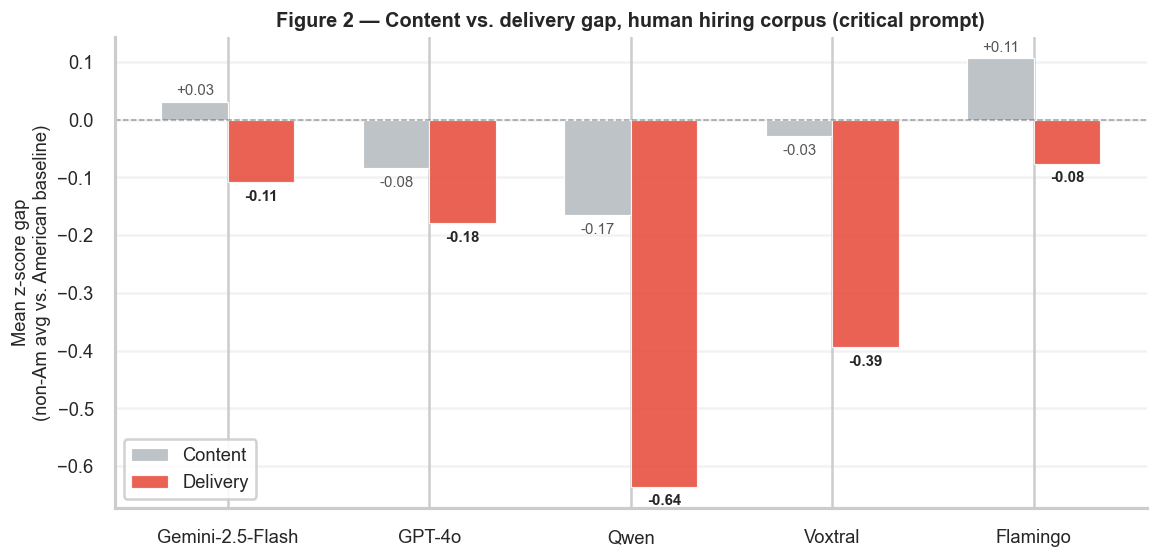

Saved: fig2a_content_vs_delivery_model_avg.pdf


In [7]:
# Figure 2a — content vs. delivery, averaged over non-American accents, per model
del_avg = (corp_del[corp_del['accent'] != 'American']
           .groupby('model_label')['gap'].mean().reindex(MODELS_ORDER))
con_avg = (corp_con[corp_con['accent'] != 'American']
           .groupby('model_label')['gap'].mean().reindex(MODELS_ORDER))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(MODELS_ORDER))
w = 0.33

bars_c = ax.bar(x - w/2, con_avg, w, label='Content',
                color='#bdc3c7', edgecolor='white', linewidth=0.7)
bars_d = ax.bar(x + w/2, del_avg, w, label='Delivery',
                color='#e74c3c', edgecolor='white', linewidth=0.7, alpha=0.88)

for bar, v in zip(bars_c, con_avg.fillna(0)):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + (-0.013 if v < 0 else 0.006), f'{v:+.2f}',
            ha='center', va='top' if v < 0 else 'bottom', fontsize=9, color='#555')
for bar, v in zip(bars_d, del_avg.fillna(0)):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + (-0.013 if v < 0 else 0.006), f'{v:+.2f}',
            ha='center', va='top' if v < 0 else 'bottom', fontsize=9, fontweight='bold')

ax.axhline(0, color='#555', linewidth=0.9, linestyle='--', alpha=0.55)
ax.set_xticks(x)
ax.set_xticklabels(MODELS_ORDER, fontsize=AXIS_FONT_SIZE)
ax.tick_params(axis='y', labelsize=AXIS_FONT_SIZE)
ax.set_ylabel('Mean z-score gap\n(non-Am avg vs. American baseline)', fontsize=AXIS_FONT_SIZE)
ax.set_title('Figure 2 — Content vs. delivery gap, human hiring corpus (critical prompt)',
             fontsize=TITLE_FONT_SIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=11, framealpha=0.9)
fig.tight_layout()
fig.savefig(FIGS / 'fig2a_content_vs_delivery_model_avg.pdf', bbox_inches='tight')
plt.show()
print('Saved: fig2a_content_vs_delivery_model_avg.pdf')

## Figure 3 — Synthetic delivery z-score gaps (critical prompt)

**Corpus:** ElevenLabs TTS · **Prompt:** critical · **Dimension:** delivery · **n=6 voices per accent group** · 95% CI shown; results are directional given small voice count

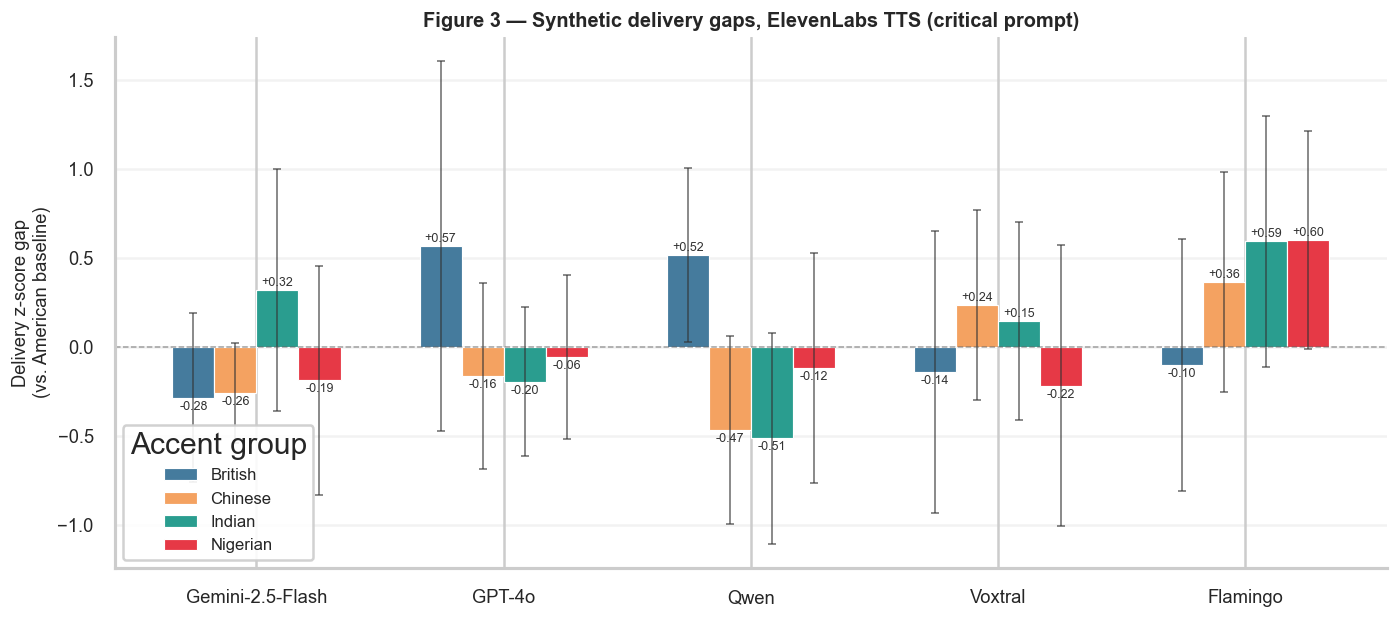

Saved: fig3a_synth_delivery_by_model.pdf


In [8]:
# 95% CI for synthetic (voice-level, 6 voices per accent)
synth_del_ci = _gap_ci(synth[synth['script_type'] == 'delivery'], 'voice_id')

synth_del_na = synth_del[synth_del['accent'] != 'American']
acc_s = [a for a in NON_AM if a in synth_del_na['accent'].unique()]

fig, ax = plt.subplots(figsize=(12, 5.5))
w       = 0.17
x       = np.arange(len(MODELS_ORDER))
offsets = np.linspace(-(len(acc_s) - 1) / 2, (len(acc_s) - 1) / 2, len(acc_s)) * w

for i, acc in enumerate(acc_s):
    vals = [float(synth_del_na[(synth_del_na['model_label'] == m) &
                                (synth_del_na['accent'] == acc)]['gap'].iloc[0])
            if len(synth_del_na[(synth_del_na['model_label'] == m) &
                                 (synth_del_na['accent'] == acc)]) else np.nan
            for m in MODELS_ORDER]
    cis  = [float(synth_del_ci[(synth_del_ci['model_label'] == m) &
                                (synth_del_ci['accent'] == acc)]['half_ci'].iloc[0])
            if len(synth_del_ci[(synth_del_ci['model_label'] == m) &
                                 (synth_del_ci['accent'] == acc)]) else np.nan
            for m in MODELS_ORDER]

    bars = ax.bar(x + offsets[i], vals, w,
                  label=acc, color=ACCENT_COLORS[acc], edgecolor='white', linewidth=0.7,
                  yerr=cis, capsize=2.5,
                  error_kw={'elinewidth': 0.9, 'ecolor': '#333', 'capthick': 0.9, 'alpha': 0.75})
    for bar, v, ci in zip(bars, vals, cis):
        if not np.isnan(v):
            ly = v + (-0.016 if v < 0 else 0.008)
            if   0 <= v < 0.025:  ly =  0.013
            elif -0.025 < v < 0:  ly = -0.013
            ax.text(bar.get_x() + bar.get_width() / 2, ly, f'{v:+.2f}',
                    ha='center', va='top' if v < 0 else 'bottom', fontsize=7.5, color='#333')

ax.axhline(0, color='#555', linewidth=0.9, linestyle='--', alpha=0.55)
ax.set_xticks(x)
ax.set_xticklabels(MODELS_ORDER, fontsize=AXIS_FONT_SIZE)
ax.tick_params(axis='y', labelsize=AXIS_FONT_SIZE)
ax.set_ylabel('Delivery z-score gap\n(vs. American baseline)', fontsize=AXIS_FONT_SIZE)
ax.set_title('Figure 3 — Synthetic delivery gaps, ElevenLabs TTS (critical prompt)',
             fontsize=TITLE_FONT_SIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Accent group', framealpha=0.9, fontsize=10, loc='lower left')
fig.tight_layout()
fig.savefig(FIGS / 'fig3a_synth_delivery_by_model.pdf', bbox_inches='tight')
plt.show()
print('Saved: fig3a_synth_delivery_by_model.pdf')

## Figure 4 — Prompt sensitivity (all three framings)

**Corpus:** Human hiring · **Prompts:** critical, ideal, native (all three, shown separately) · **Dimension:** delivery · **Gap:** averaged over non-American accents vs. American baseline

This figure requires all three prompt types, so the full corpus is loaded here separately from the critical-only `corpus` used in Figures 1–3.

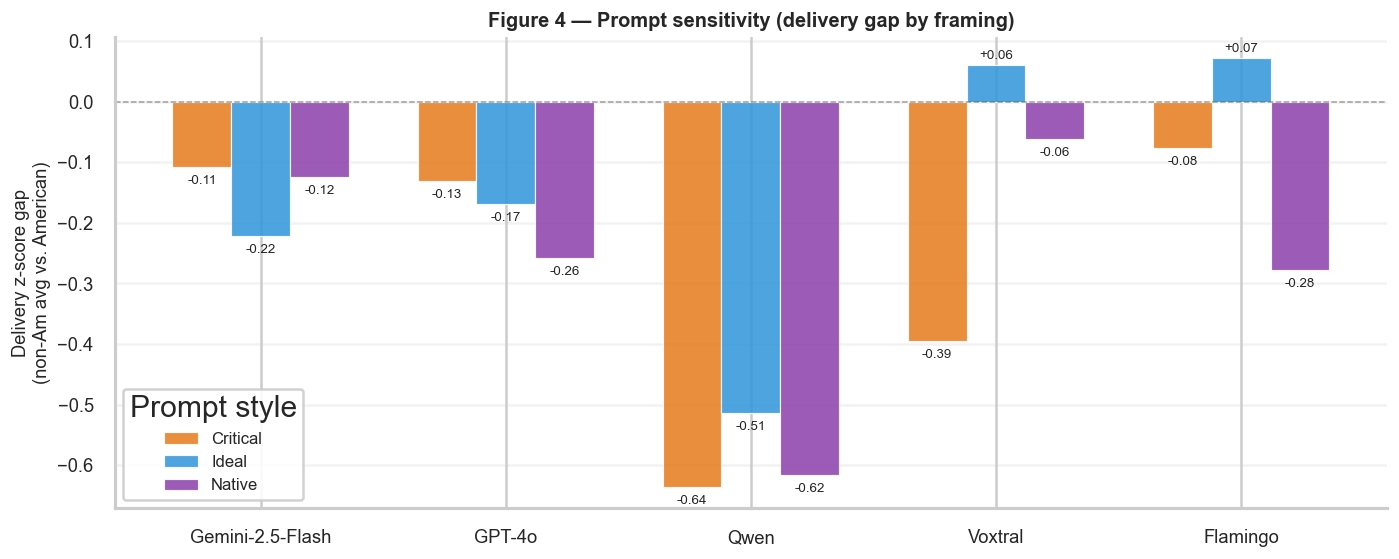

Saved: fig4a_prompt_sensitivity_by_model.pdf


In [9]:
# Load full corpus (all 3 prompt types) for prompt sensitivity
corpus_full_parts = []
for mlabel, fname in CORPUS_FILES.items():
    p = ROOT / 'results' / 'hiring_corpus' / fname
    if not p.exists():
        continue
    df = pd.read_csv(p)
    df['model_label'] = mlabel
    corpus_full_parts.append(df)

corpus_full = pd.concat(corpus_full_parts, ignore_index=True)
corpus_full['rating'] = corpus_full['model_output'].apply(_extract_rating)
corpus_full['accent'] = corpus_full['accent_nationality_origin'].apply(_normalize_accent)
corpus_full = corpus_full[corpus_full['accent'].notna() & corpus_full['rating'].notna()].copy()
corpus_full = _zscore(corpus_full, ['model_label', 'prompt_type', 'script_type', 'category'])

PROMPT_ORDER = ['critical', 'ideal', 'native']
PT_COLORS    = {'critical': '#e67e22', 'ideal': '#3498db', 'native': '#8e44ad'}

by_pt      = corpus_full[corpus_full['script_type'] == 'delivery'].copy()
by_pt_cell = by_pt.groupby(['model_label', 'prompt_type', 'accent'])['z'].mean().reset_index()
am_by_pt   = (by_pt_cell[by_pt_cell['accent'] == 'American']
              .groupby(['model_label', 'prompt_type'])['z'].mean())
by_pt_cell['gap'] = by_pt_cell.apply(
    lambda r: r['z'] - am_by_pt.get((r['model_label'], r['prompt_type']), 0.0), axis=1)
pt_avg = (by_pt_cell[by_pt_cell['accent'] != 'American']
          .groupby(['model_label', 'prompt_type'])['gap'].mean().reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(MODELS_ORDER))
w       = 0.24
offsets = [-w, 0, w]

for i, pt in enumerate(PROMPT_ORDER):
    vals = [float(pt_avg[(pt_avg['model_label'] == m) & (pt_avg['prompt_type'] == pt)]['gap'].iloc[0])
            if len(pt_avg[(pt_avg['model_label'] == m) & (pt_avg['prompt_type'] == pt)]) else 0.0
            for m in MODELS_ORDER]
    bars = ax.bar(x + offsets[i], vals, w,
                  label=pt.capitalize(), color=PT_COLORS[pt],
                  edgecolor='white', linewidth=0.7, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + (-0.013 if v < 0 else 0.006), f'{v:+.2f}',
                ha='center', va='top' if v < 0 else 'bottom', fontsize=8)

ax.axhline(0, color='#555', linewidth=0.9, linestyle='--', alpha=0.55)
ax.set_xticks(x)
ax.set_xticklabels(MODELS_ORDER, fontsize=AXIS_FONT_SIZE)
ax.tick_params(axis='y', labelsize=AXIS_FONT_SIZE)
ax.set_ylabel('Delivery z-score gap\n(non-Am avg vs. American)', fontsize=AXIS_FONT_SIZE)
ax.set_title('Figure 4 — Prompt sensitivity (delivery gap by framing)',
             fontsize=TITLE_FONT_SIZE, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Prompt style', fontsize=10, framealpha=0.9)
fig.tight_layout()
fig.savefig(FIGS / 'fig4a_prompt_sensitivity_by_model.pdf', bbox_inches='tight')
plt.show()
print('Saved: fig4a_prompt_sensitivity_by_model.pdf')